In [7]:
%load_ext autoreload
%autoreload 2


import numpy as np
import pandas as pd
import torch
import pydicom
import matplotlib.pyplot as plt

from pathlib import Path

# MONAI imports
import monai
from monai.data import Dataset, CacheDataset, DataLoader, PILReader
from monai.transforms import (
    LoadImage, LoadImaged, Resized, Compose, SaveImage, 
    Spacingd, SpatialCropd, ResizeWithPadOrCropd
)

import numpy as np
from monai.transforms import (
    Compose,
    LoadImaged,
    Transposed,
    NormalizeIntensityd,
    MapTransform,
    ScaleIntensityRangePercentilesd,
    RandAffined, RandGaussianNoised, 
    RandStdShiftIntensityd, RandScaleIntensityd, RandAdjustContrastd, RandHistogramShiftd,
    ScaleIntensityd, Lambdad,
    LoadImage, Transpose
)

from torch.utils.data import DataLoader
from tqdm.notebook import tqdm



import landmarker
import landmarker.datasets
from landmarker.datasets import get_cepha_landmark_datasets
from landmarker.heatmap import GaussianHeatmapGenerator, LaplacianHeatmapGenerator
from landmarker.models import OriginalSpatialConfigurationNet
from landmarker.losses import GaussianHeatmapL2Loss
from torch.utils.data import DataLoader
from landmarker.visualize import inspection_plot
from landmarker.visualize.utils import prediction_inspect_plot, prediction_inspect_plot_transposed, inspection_plot_numbers

from landmarker.visualize import detection_report
from landmarker.visualize.evaluation import detection_report, convert_to_report_df, evaluate_model_on_loader

from landmarker.data import LandmarkDataset

#   My stuff
import landmarks_utils
import landmarks_utils.data.data_utils
from  landmarks_utils.data.data_utils import (
    extract_extras_from_filename, 
    extract_extras_from_abspath
)

import landmarks_utils.visualization.plot_landmarks
import landmarks_utils.data
import landmarks_utils.data.dataloader_CR_landmarks
import landmarks_utils.visualization.plot_landmarks #.plot_landmarks
import pydicom
import numpy as np

import pydicom
import numpy as np
import pandas as pd


import numpy as np
from sklearn.model_selection import KFold
from landmarks_utils.utils.config_parser import load_config
import os 
from landmarker.heatmap.decoder import heatmap_to_coord
from landmarker.metrics import point_error


from landmarks_utils.inference.landmarks_inference_v2 import load_models_and_settings
from landmarks_utils.training.landmarks.lib import (
    get_transforms
    )


from landmarks_utils.data.data_handler_landmarks_generic import DataHandler_CR_autoscoRA_generic



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
## INPUT: 
#config = "/home/cwatzenboeck/code/RA/landmarks_utils/runs/config_landmarks/feet/F_train_landmarks_102.yaml"
config = "/home/cwatzenboeck/code/RA/landmarks_utils/runs/config_landmarks/feet/F_train_landmarks_102p1__updated_data_handler.yaml"
config_inference = "/home/cwatzenboeck/code/RA/landmarks_utils/runs//config_landmarks/inference/F_inference_580_cases.yaml"

config = load_config(config, debugging_in_jupyter_nb=True, silencium=True)
config_inference = load_config(config_inference, debugging_in_jupyter_nb=True, silencium=True)
config_inference


{'debugging': False,
 'model': {'mlflow_runs_dir': '/home/cwatzenboeck/data/mlflow_cirpc_tmp/RA/data/',
  'run_id': 'de8519d266a6402f91f66d54d9e96f6f',
  'model_artifact_name': 'best_model',
  'heatmap_generator_artifact_name': 'best_heatmap_generator'},
 'input': {'image_folder': '/home/cwatzenboeck/data/AutoPIX_cirdata/projects__autoscora/autoscoRA_images/F_images_of_interest_2_renamed_mirrored_inverted_dicoms'},
 'output_dst': '/home/cwatzenboeck/data/AutoPIX_cirdata/projects__autoscora/landmark_data/output/F_coordinates__580Tr_de8519d266a6402f91f66d54d9e96f6f.csv'}

In [9]:
# Load model
model, heatmap_generator, settings = load_models_and_settings(config_inference)



In [10]:
# list(heatmap_generator.named_parameters())

In [11]:


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)


cuda


In [12]:
settings = config["data_settings"]
dataHandler = DataHandler_CR_autoscoRA_generic(
    folder_images=settings["folder_images"],
    df_lm_labels=settings["landmarks_csv"],
    training_test_splits_json=settings["training_test_splits_json"],
    df_autoscoRA_labels_header=settings.get("df_autoscoRA_labels_header", "infer")
)


In [14]:
(
    image_paths_train,
    image_paths_test1,
    image_paths_test2,
    landmarks_train,
    landmarks_test1,
    landmarks_test2,
    pixel_spacings_train,
    pixel_spacings_test1,
    pixel_spacings_test2
) = dataHandler.get_landmarks_dataset(
    get_pixel_spacing=config["model_settings"].get("get_pixel_spacing", False), 
    pixel_spacing_default = config["model_settings"].get("pixel_spacing_default", [0.1, 0.1])
)
lm_names = dataHandler.landmark_names


In [18]:
## Make datesets 
if not isinstance(pixel_spacings_train, (list, tuple, np.ndarray)) or pixel_spacings_train is None:
    pixel_spacings_train = (0.1, 0.1)
if not isinstance(pixel_spacings_test1, (list, tuple, np.ndarray)) or pixel_spacings_test1 is None:
    pixel_spacings_test1 = (0.1, 0.1)
if not isinstance(pixel_spacings_test2, (list, tuple, np.ndarray)) or pixel_spacings_test2 is None:
    pixel_spacings_test2 = (0.1, 0.1)

# Make dataset
dim_image = config["model_settings"]["dim_image"]
train_transformd, inference_transformd = get_transforms(config)


import landmarks_utils.data.dataloader_CR_landmarks
#ds_train, ds_test1, ds_test2 = landmarks_utils.data.dataloader_CR_landmarks.get_landmark_datasets(
    
ds_train, ds_test1, ds_test2 = landmarks_utils.data.dataloader_CR_landmarks.get_landmark_datasets_v2(
    image_paths_train=image_paths_train,
    image_paths_test1=image_paths_test1,
    image_paths_test2=image_paths_test2,
    landmarks_train=landmarks_train,
    landmarks_test1=landmarks_test1,
    landmarks_test2=landmarks_test2,
    pixel_spacings_train=pixel_spacings_train,
    pixel_spacings_test1=pixel_spacings_test1,
    pixel_spacings_test2=pixel_spacings_test2,
    train_transform=train_transformd,
    inference_transform=inference_transformd,
    dim_img=dim_image,
    class_names=lm_names
)

N_landmarks = landmarks_train.shape[1]


In [19]:
heatmap_generator.to("cpu")

GaussianHeatmapGenerator()

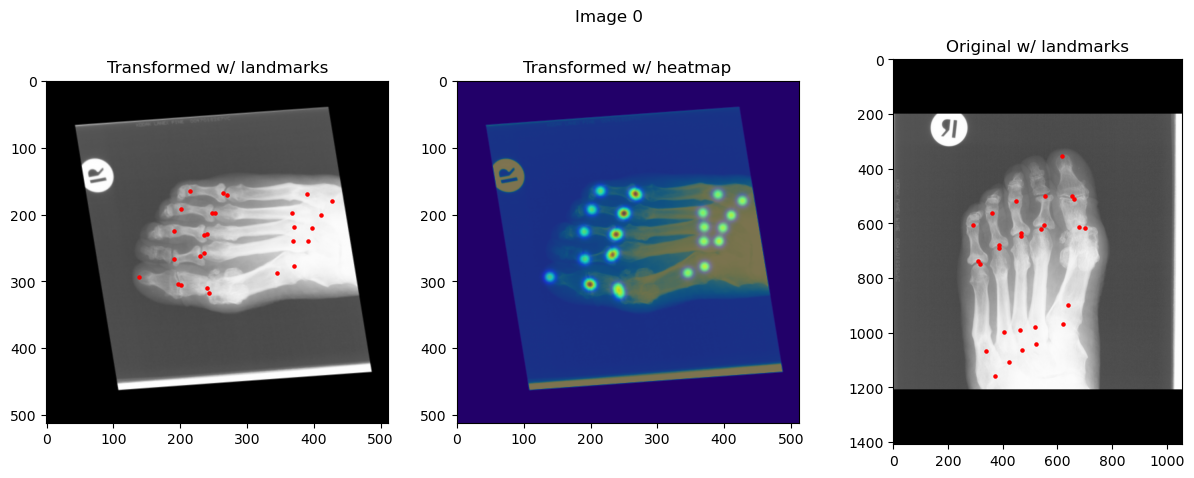

In [20]:
# Plot the first 3 images from the training set
inspection_plot(ds_train, range(0,1), heatmap_generator=heatmap_generator)


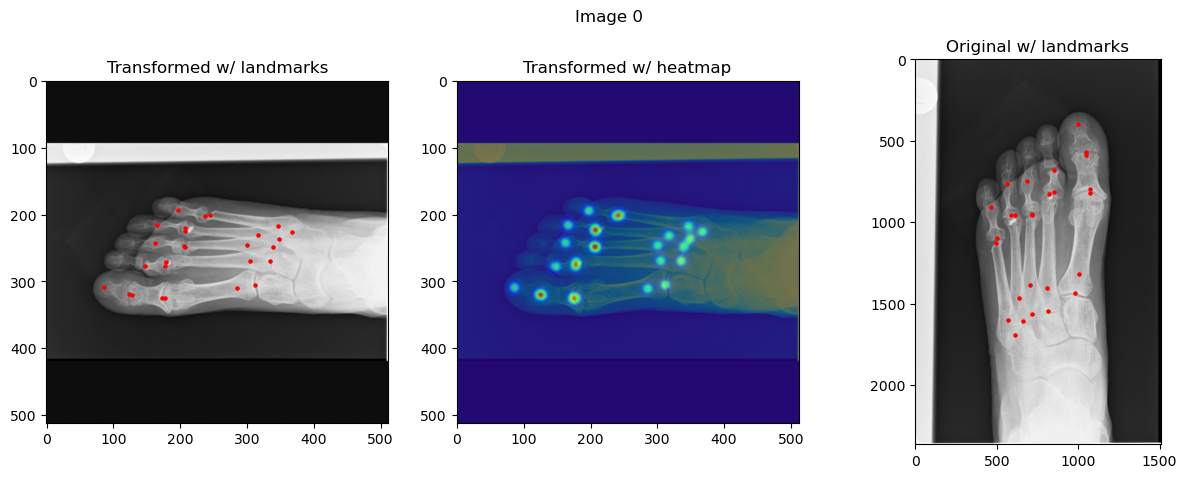

In [21]:
# Plot the first 3 images from dataset without transforms
#heatmap_generator.device = "cpu" # because dataset tensors are still on cpu
inspection_plot(ds_test1, 0, heatmap_generator=heatmap_generator)
heatmap_generator.device = device # set the desired device back

### Evaluate model: 

In [22]:
## Set up dataloaders
batch_size = 1
train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(ds_test1, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(ds_test2, batch_size=batch_size, shuffle=False, num_workers=0)

In [23]:
# Evaluate model on test set
results = evaluate_model_on_loader(
    model=model,
    test_loader=test_loader,
    device=device
)
pred_landmarks = results["pred_landmarks"]
true_landmarks = results["true_landmarks"]
pixel_spacings = results["pixel_spacings"]
dim_origs = results["dim_origs"]
paddings = results["paddings"]
test_mpes = results["test_mpes"]
test_mpe = test_mpes.mean()

print(f"Test Mean PE: {test_mpe:.4f}")



  0%|          | 0/19 [00:00<?, ?it/s]WARNING:pydicom:Error while processing tag 00080050: The value length (64) exceeds the maximum length of 16 allowed for VR SH.


100%|██████████| 19/19 [00:04<00:00,  4.15it/s]

Test Mean PE: 1.4132


In [24]:
worst_prediction = test_mpes.argsort()[:][::-1]
print(worst_prediction)
print(test_mpes[worst_prediction])



[13 11 14 15  9  5 17  2 12 16  0 18  3  1  8  7  4 10  6]
[2.4483352 1.9623811 1.8916498 1.619639  1.5000596 1.4821159 1.4419125
 1.40152   1.383578  1.3831671 1.2880834 1.2802109 1.2318262 1.1926703
 1.178373  1.1636405 1.0898896 1.0411278 0.8711257]


In [25]:
from landmarker.metrics import sdr

sdr_test = sdr([2.0, 2.5, 3.0, 4.0], true_landmarks=true_landmarks, pred_landmarks=pred_landmarks,
               dim=(512, 512), dim_orig=dim_origs.int(), pixel_spacing=pixel_spacings, padding=paddings)
for key in sdr_test:
    print(f"SDR for {key}mm: {sdr_test[key]:.4f}")


    

SDR for 2.0mm: 79.3372
SDR for 2.5mm: 86.1598
SDR for 3.0mm: 89.2788
SDR for 4.0mm: 95.1267


Median predictions


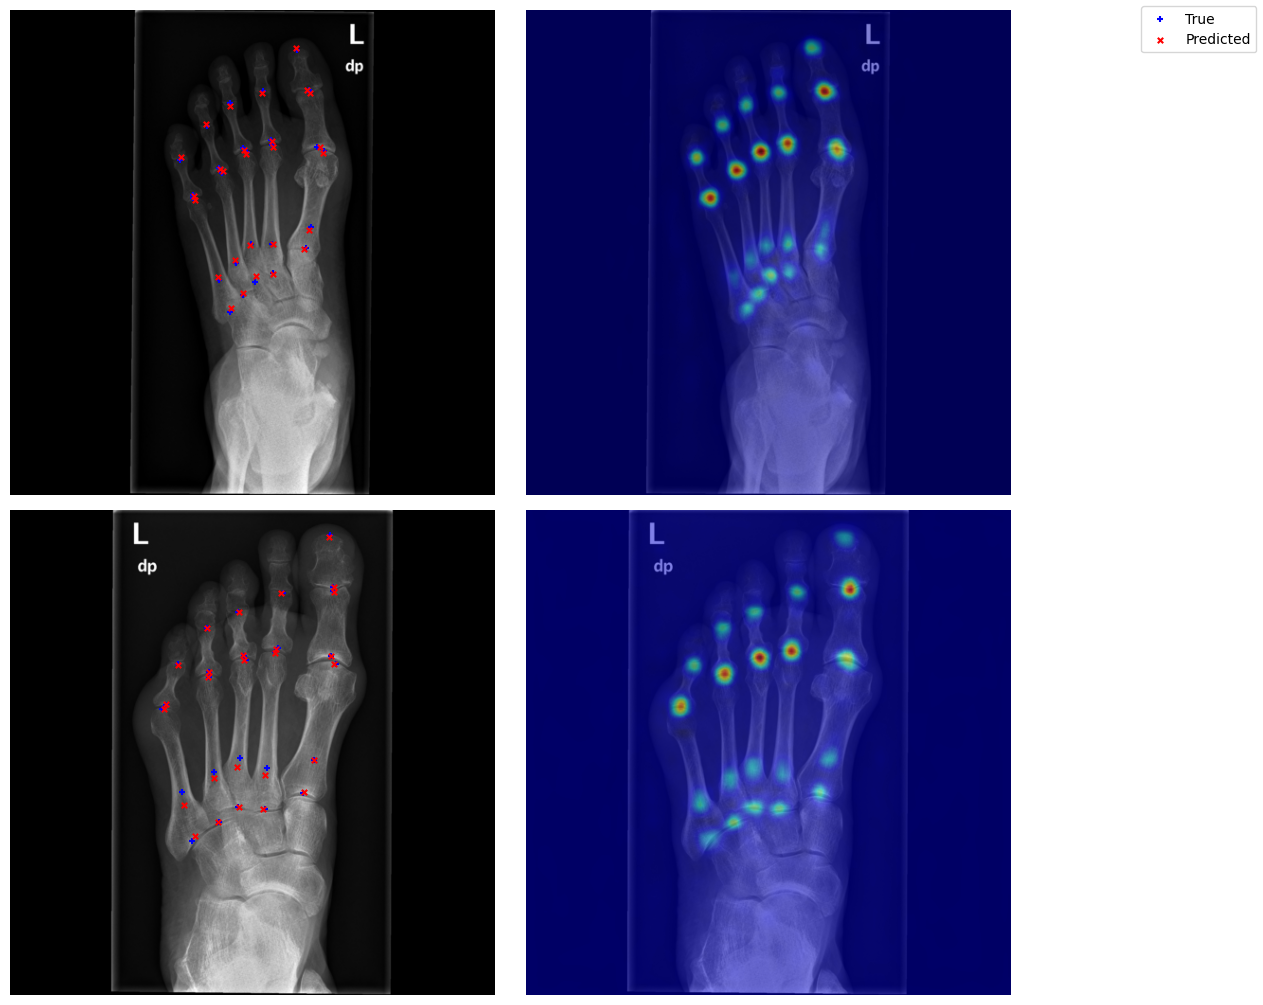

Worst predictions


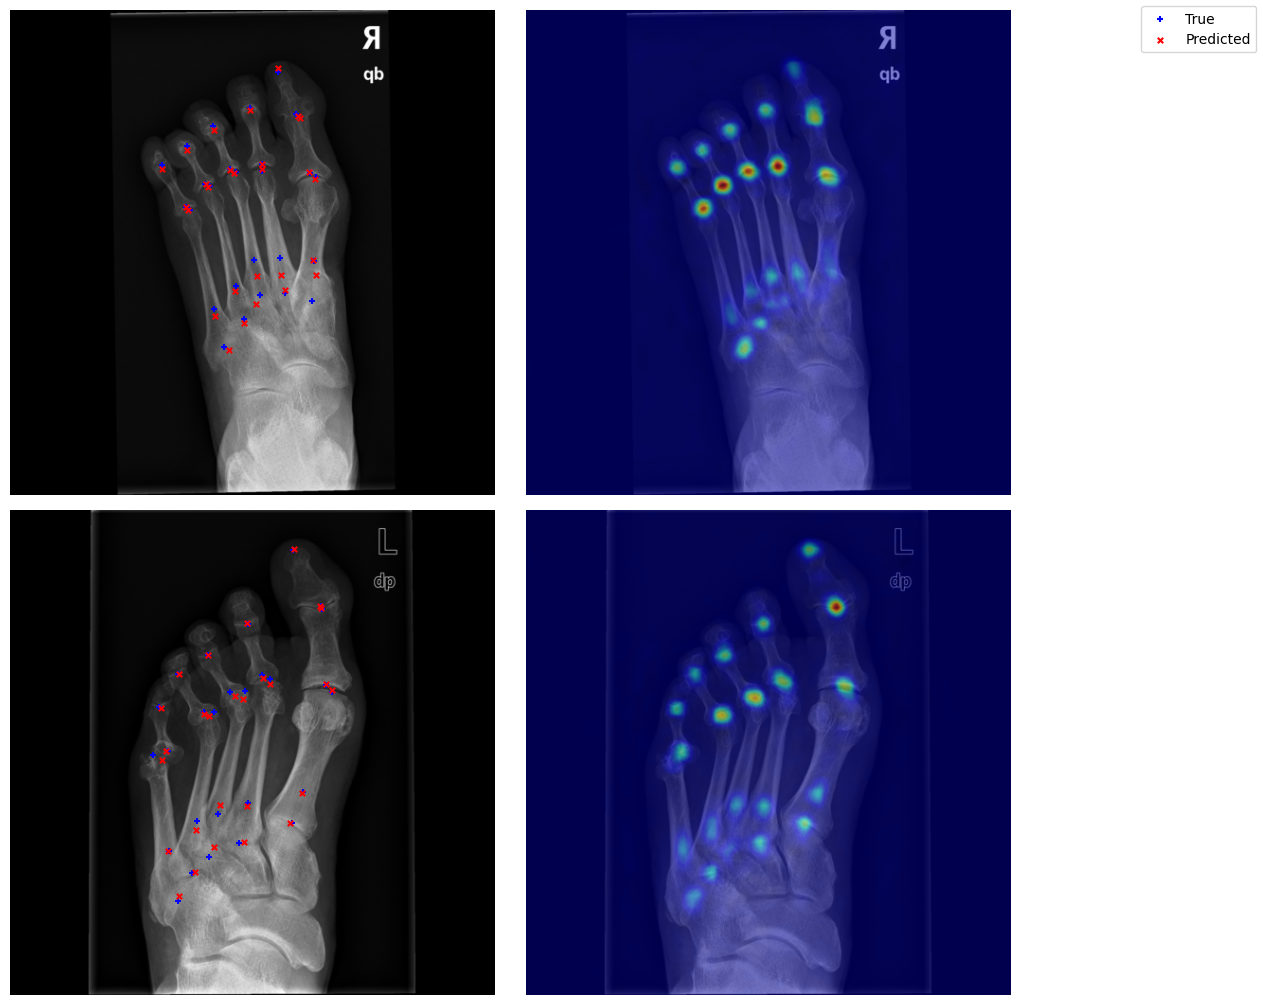

In [26]:

model.eval()
model.to("cpu")

# print("Best predictions")
# best_predictions = worst_prediction[-2:]
# prediction_inspect_plot_transposed(ds_test2, model, best_predictions) #ds_test2.indices[:3])

print("Median predictions")
medium_predictions = worst_prediction[len(worst_prediction)//2-1: len(worst_prediction)//2+1]
prediction_inspect_plot_transposed(ds_test2, model, medium_predictions) #ds_test2.indices[:3])


print("Worst predictions")
prediction_inspect_plot_transposed(ds_test2, model, worst_prediction[:2])


In [39]:
report = detection_report(true_landmarks, pred_landmarks, dim=(512, 512), dim_orig=dim_origs.int(),
                    pixel_spacing=pixel_spacings, padding=paddings, class_names=ds_train.class_names,
                    #radius=[2.0, 5.0, 10.0], 
                    radius=[1.0, 2.0, 5.0, 10.0], 
                    digits=2, output_dict=True, print_report=False)


report = convert_to_report_df(report)
report_rounded = report.copy()
# Round SDR columns to 0 digits, other columns to 2 digits
report_rounded = report_rounded.sort_values("SDR < 02.0", ascending=False)
for col in report.columns:
    if col.startswith('SDR'):
        report_rounded[col] = report_rounded[col].apply(lambda x: str(int(np.round(x))) + "%")
    else:
        report_rounded[col] = report_rounded[col].round(2)
report_rounded

,Max,Mean,Median,Min,SDR < 01.0,SDR < 02.0,SDR < 05.0,SDR < 10.0,Std
MTP5-D,1.40,0.59,0.49,0.04,84%,100%,100%,100%,0.40
MTP2-D,1.58,0.77,0.71,0.12,69%,100%,100%,100%,0.44
FIP4-P,1.74,0.86,0.72,0.12,64%,100%,100%,100%,0.43
MTP4-D,1.49,0.61,0.52,0.20,88%,100%,100%,100%,0.30
FIP5-P,1.78,0.86,0.77,0.06,66%,100%,100%,100%,0.46
FIP1-D,2.06,0.88,0.92,0.17,70%,95%,100%,100%,0.45
MTP3-D,2.93,0.77,0.62,0.25,83%,95%,100%,100%,0.58
FIP1-P,2.85,0.89,0.76,0.23,67%,95%,100%,100%,0.55
MTP3-P,4.33,1.01,0.84,0.04,67%,94%,100%,100%,0.88
FIP3-P,3.10,0.94,0.74,0.14,71%,94%,100%,100%,0.70


In [40]:
report.to_csv("/home/cwatzenboeck/code/RA/landmarks_utils/documentation/results/SDR_F_580c_2025-08-07.csv")

In [ ]:



report["SDR < 02.0"].mean(), report["SDR < 05.0"].mean(), report["SDR < 10.0"].mean()

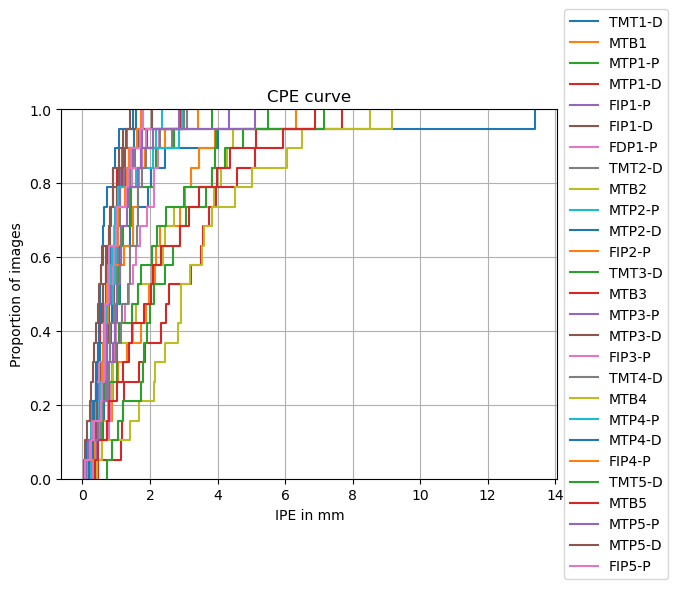

In [ ]:
# Ugly but general plot

from landmarker.visualize import plot_cpe

plot_cpe(true_landmarks, pred_landmarks, dim=(512, 512), dim_orig=dim_origs.int(),
                    pixel_spacing=pixel_spacings, padding=paddings, class_names=ds_train.class_names,
                    group=False, title="CPE curve", save_path=None,
                    stat='proportion', unit='mm', kind='ecdf')

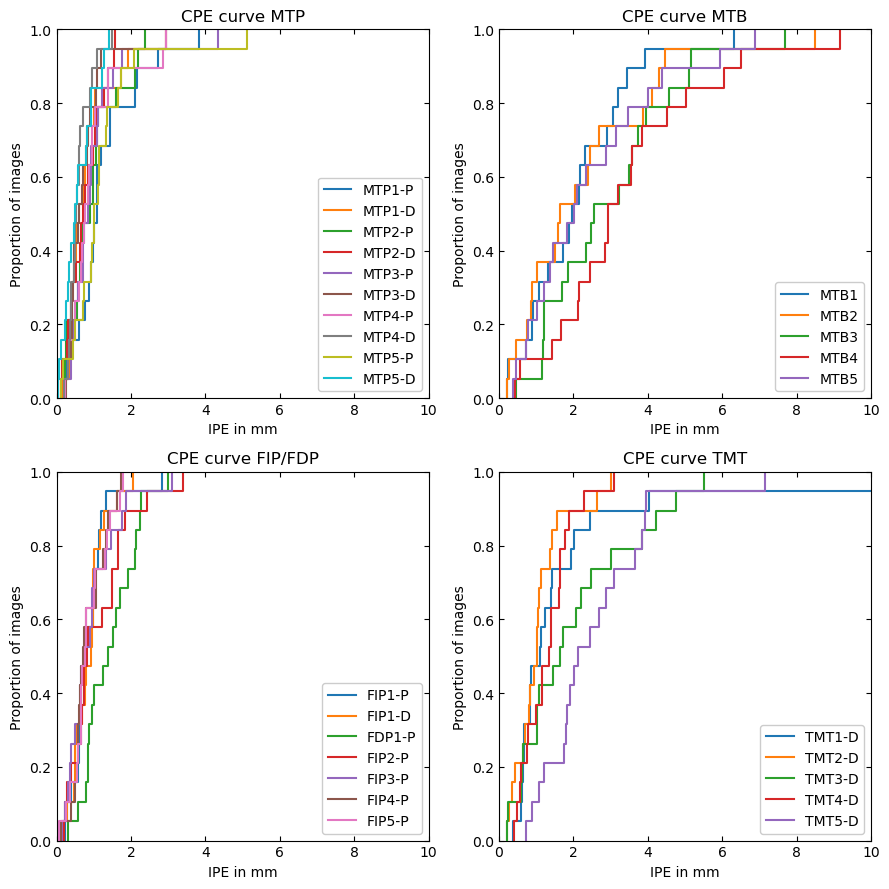

In [38]:
### Plot cumulative point error 

import re
import matplotlib.pyplot as plt
import numpy as np

class_names = np.array(ds_train.class_names)

# Define patterns for different groups
mtp_pattern = r"^MTP"
mtb_pattern = r"^MTB"
fip_pattern = r"^FIP|^FDP"
tmt_pattern = r"^TMT"

# Get indices for each group
mtp_indices = [i for i, x in enumerate(class_names) if re.match(mtp_pattern, x)]
mtb_indices = [i for i, x in enumerate(class_names) if re.match(mtb_pattern, x)]
fip_indices = [i for i, x in enumerate(class_names) if re.match(fip_pattern, x)]
tmt_indices = [i for i, x in enumerate(class_names) if re.match(tmt_pattern, x)]

# Check if all landmarks are assigned
all_indices = set(range(len(class_names)))
used_indices = set(mtp_indices + fip_indices + tmt_indices + mtb_indices)
rest_indices = sorted(list(all_indices - used_indices))
assert len(rest_indices) == 0, class_names[rest_indices]

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
axes = axes.flatten()
x_max = 10.0  # <- Add this line for shared x-axis max

# Plot for each group
groups = [(mtp_indices, "MTP"), (mtb_indices, "MTB"),
          (fip_indices, "FIP/FDP"), (tmt_indices, "TMT")]

for (indices, title), ax in zip(groups, axes):
    plot_cpe(true_landmarks[:, indices, :], pred_landmarks[:, indices, :],
             dim=(512, 512), dim_orig=dim_origs.int(),
             pixel_spacing=pixel_spacings, padding=paddings,
             class_names=class_names[indices],
             group=False, title="", save_path=None,
             stat='proportion', unit='mm', kind='ecdf', ax=ax)

    ax.set_title(f"CPE curve {title}")
    ax.set_xlim(0, x_max)  # <- Set same x-axis range
    ax.legend(loc='lower right')
    ax.get_legend().get_frame().set_alpha(1.0)
    ax.tick_params(axis='both', direction='in', top=True, right=True)
    ax.grid(False)

plt.tight_layout()
plt.show()
